In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# --------- PATHS ----------
base_dir = "/Users/ryansenne/Desktop/Dill"
ddir = os.path.join(base_dir, "fc_traces_csv")

# get the list of all .csv files containing "astro" in the name
csv_files = [
    f for f in os.listdir(ddir)
    if f.endswith("accepted_traces.csv") and "astro" in f
]

# READ IN TRUE TIMESTAMPS FOR ALL
true_time = pd.read_csv(os.path.join(base_dir, "time.csv")).to_numpy().squeeze()
time_mask = (10 <= true_time) & (true_time <= 330)
time_mask = time_mask.squeeze()

# read each file into a dict of DataFrames
named_dfs = {
    fname: pd.read_csv(os.path.join(ddir, fname))
    for fname in csv_files
}

# --------- PREPROCESSING ----------
def process_df(df: pd.DataFrame) -> np.ndarray:
    """
    For each file:
      - First column is time.
      - Subsequent columns are cells.
      - Skip first ~100 rows.
      - Sum across cells -> 1D activity vector (ignore time column).
    """
    # skip first 100 indices (Julia's 100:end is 1-based; here use 99: for 0-based)
    # slice rows 99: and columns 1: (drop time column)
    activity = df.iloc[99:3301, 1:]
    summed = activity.to_numpy().sum(axis=1)
    return summed.astype(float)

def detect_sequences_simple(
    data: np.ndarray,
    k: float = 1.0,
    min_duration: int = 20,
    separation_duration: int = 100,
):
    """
    1) Compute mean μ and std σ of data.
    2) Mark indices where data > μ + kσ.
    3) Group consecutive indices into sequences.
    4) Keep sequences with length ≥ min_duration.
    5) Merge sequences whose gaps ≤ separation_duration.

    Returns:
        list of lists of indices (0-based).
    """
    μ = data.mean()
    σ = data.std()
    thr = μ + k * σ

    # all indices above threshold
    idx = np.where(data > thr)[0]
    if idx.size == 0:
        return []

    # group consecutive indices
    groups = []
    current = [int(idx[0])]
    for i in range(1, len(idx)):
        if idx[i] == idx[i-1] + 1:
            current.append(int(idx[i]))
        else:
            groups.append(current)
            current = [int(idx[i])]
    groups.append(current)

    # enforce minimum duration
    groups = [g for g in groups if len(g) >= min_duration]

    # merge groups that are close in time
    if not groups:
        return []

    merged = []
    acc = groups[0]
    for g in groups[1:]:
        if g[0] - acc[-1] <= separation_duration:
            acc = acc + g
        else:
            merged.append(acc)
            acc = g
    merged.append(acc)

    return merged

results = {}

for key, df in named_dfs.items():
    data = process_df(df)
    events = detect_sequences_simple(
        data,
        k=1.5,
        min_duration=20,
        separation_duration=100,
    )

    results[key] = {
        "activity": data,
        "events": events,
    }

def plot_file_results(file_key: str, results: dict, freeze_vector: np.ndarray = None):
    result = results[file_key]
    data = result["activity"]
    events = result["events"]

    time = np.linspace(5, 330, len(data))  # simple index-based time

    fig, ax = plt.subplots()
    ax.plot(time, data, label="Summed Activity")
    ax.set_xlabel("Time (index)")
    ax.set_ylabel("Activity")
    ax.set_title(file_key)

    # highlight sequences
    ymax = data.max()
    for seq in events:
        start = time[seq[0]]
        end = time[seq[-1]]
        ax.axvspan(start, end, alpha=0.25, color="red")

        # plot freeze vector if provided
        if freeze_vector is not None:
            len_time = 3602
            len_freeze = len(freeze_vector)
            min_time = min(len_time, len_freeze)

            # keep your existing alignment logic
            x = true_time[time_mask][:min_time]
            f = freeze_vector[time_mask[:min_time]]

            # 1) only keep entries where freeze == 1
            keep = (f == 1)

            # 2) smaller markers via s=5 (tweak as needed)
            ax.scatter(
                x[keep],
                f[keep] * ymax * 0.9,
                s=0.25,
                color="black",
                alpha=0.5,
            )


    ax.legend()
    plt.tight_layout()


In [ ]:
# run and save plots for FC data
for file in csv_files:
    plot_file_results(file, results, freeze_vector=None)
    plt.savefig(base_dir + r"\seq_plots" + f"{file}_sequences.svg")
    

astroF10_cxta_accepted_traces.csv <-> astroF10_freeze_vec_cxt_a.csv
astroF3_cxta_accepted_traces.csv <-> astroF3_freeze_vec_cxt_a.csv
astroF5_cxta_accepted_traces.csv <-> astroF5_freeze_vec_cxt_a.csv
astroF6_cxta_accepted_traces.csv <-> astroF6_freeze_vec_cxt_a.csv
astroF7_cxta_accepted_traces.csv <-> astroF7_freeze_vec_cxt_a.csv
astroF9_cxta_accepted_traces.csv <-> astroF9_freeze_vec_cxt_a.csv
astroM10_cxta_accepted_traces.csv <-> astroM10_freeze_vec_cxt_a.csv
astroM3_cxta_accepted_traces.csv <-> astroM3_freeze_vec_cxt_a.csv
astroM4_cxta_accepted_traces.csv <-> astroM4_freeze_vec_cxt_a.csv
astroM5_cxta_accepted_traces.csv <-> astroM5_freeze_vec_cxt_a.csv
astroM9_cxta_accepted_traces.csv <-> astroM9_freeze_vec_cxt_a.csv


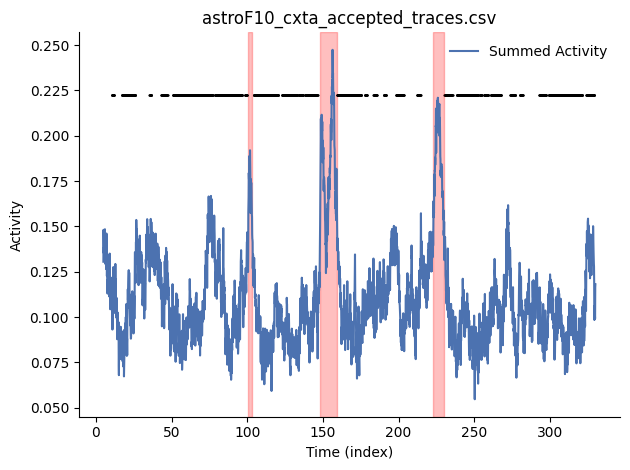

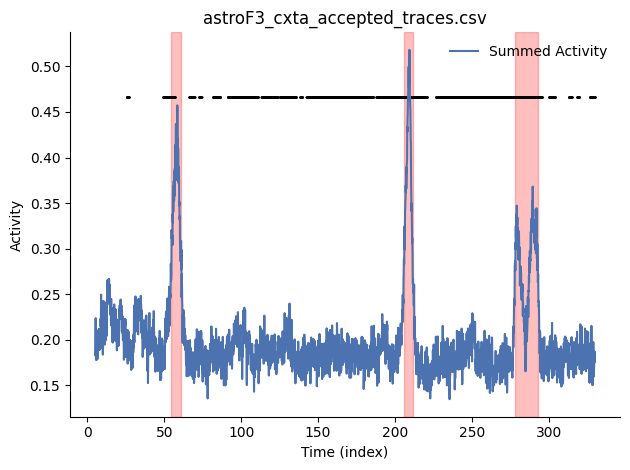

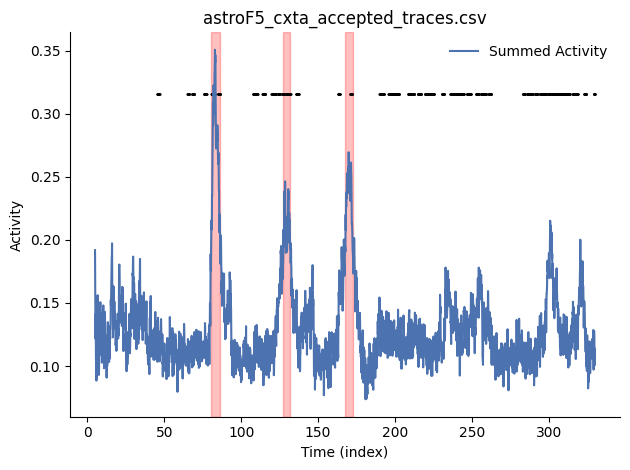

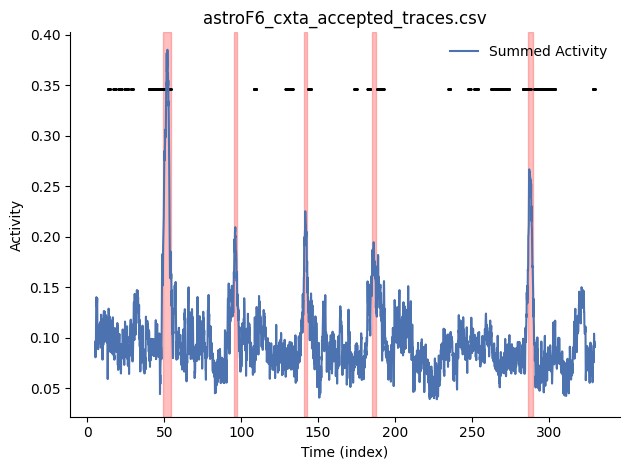

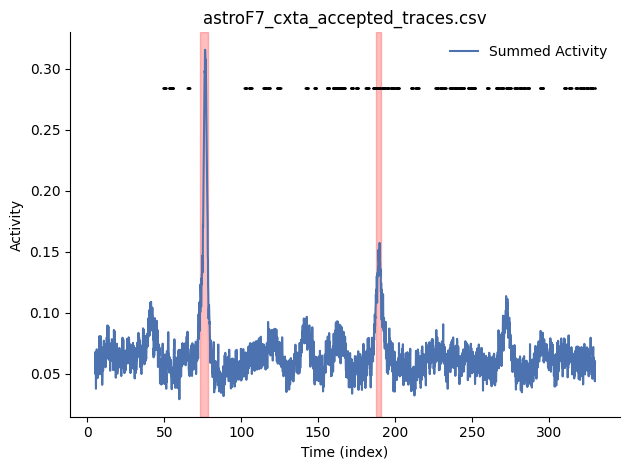

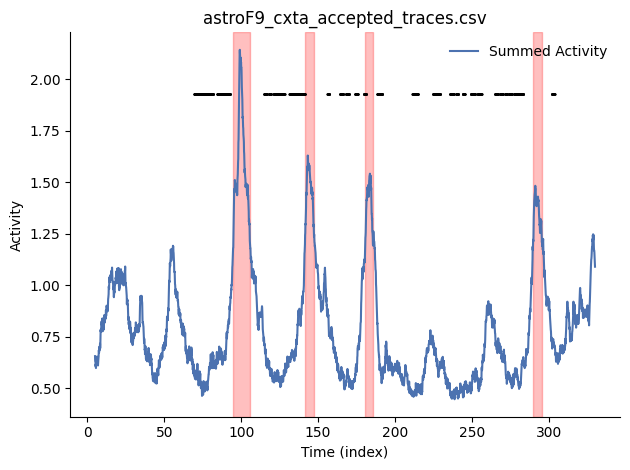

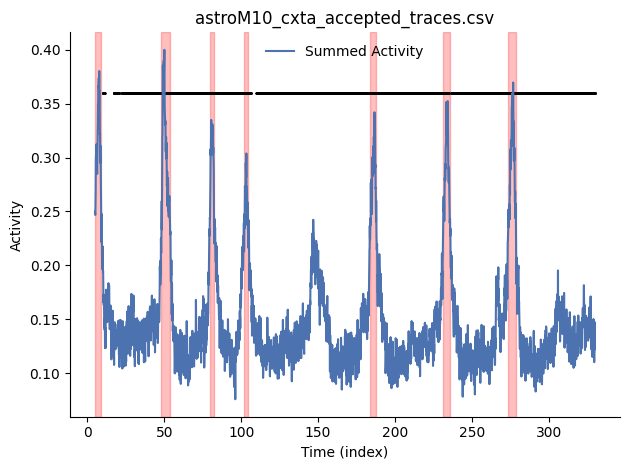

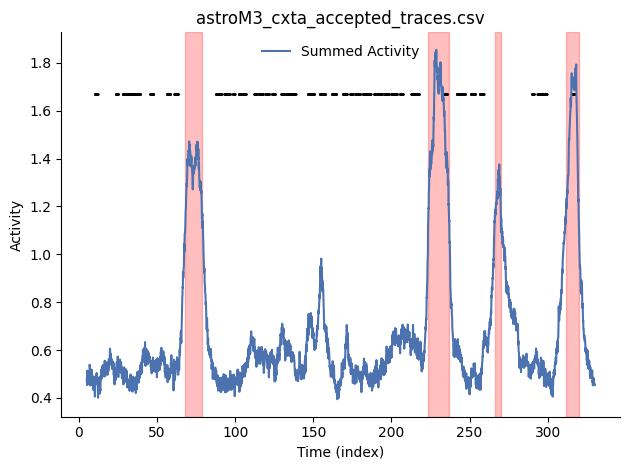

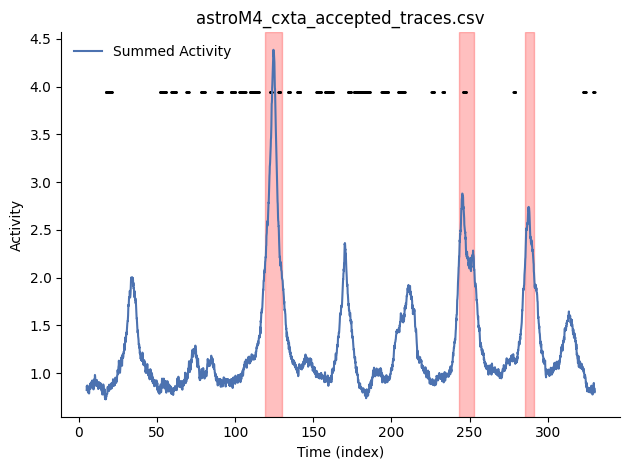

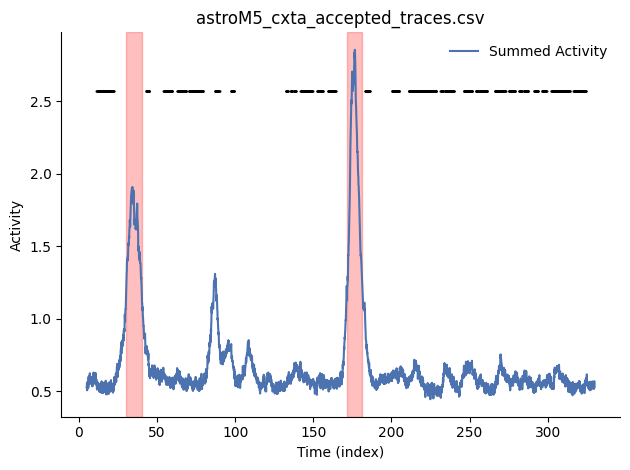

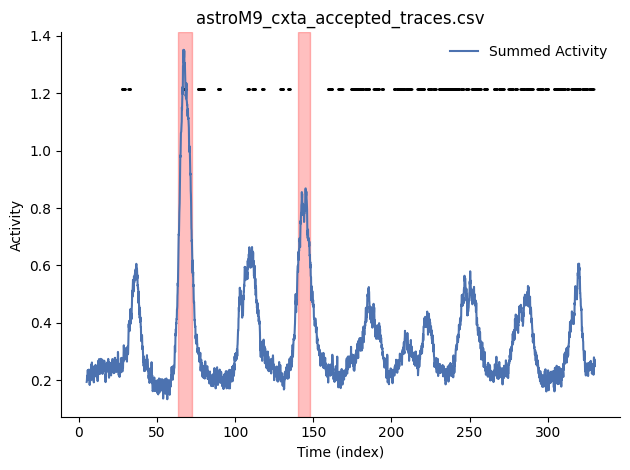

In [4]:
ddir_a = os.path.join(base_dir, "cxta_traces_csv")

# build dicts keyed by a shared base name
csv_files_a = {
    f.replace("_accepted_traces.csv", ""): f
    for f in os.listdir(ddir_a)
    if f.endswith("accepted_traces.csv") and "astro" in f
}

time_vecs_a = {
    f.replace("_freeze_vec_cxt_a.csv", ""): f
    for f in os.listdir(ddir_a)
    if f.endswith("freeze_vec_cxt_a.csv")
}

# read each traces file into a dict of DataFrames
named_dfs_a = {
    fname: pd.read_csv(os.path.join(ddir_a, fname))
    for fname in csv_files_a.values()
}

results_a = {}
for key, df in named_dfs_a.items():
    data = process_df(df)
    events = detect_sequences_simple(
        data,
        k=1.5,
        min_duration=20,
        separation_duration=100,
    )
    results_a[key] = {
        "activity": data,
        "events": events,
    }

# find animals that have *both* traces and freeze vecs
animal_ids = sorted(
    set(k.replace("_cxta", "") for k in csv_files_a.keys())  # astroF10_cxta -> astroF10
    & set(time_vecs_a.keys())                                # astroF10
)

for animal in animal_ids:
    trace_key = animal + "_cxta"                 # e.g. "astroF10_cxta"
    trace_file = csv_files_a[trace_key]         # "astroF10_cxta_accepted_traces.csv"
    freeze_file = time_vecs_a[animal]           # "astroF10_freeze_vec_cxt_a.csv"

    print(trace_file, "<->", freeze_file)

    time_vec = pd.read_csv(os.path.join(ddir_a, freeze_file)).to_numpy().squeeze()
    plot_file_results(trace_file, results_a, freeze_vector=time_vec)
    plt.savefig(base_dir + r"\seq_plots" + f"{trace_file}_sequences.svg")


astroF10_cxtb_accepted_traces.csv <-> astroF10_freeze_vec_cxt_b.csv
astroF3_cxtb_accepted_traces.csv <-> astroF3_freeze_vec_cxt_b.csv
astroF5_cxtb_accepted_traces.csv <-> astroF5_freeze_vec_cxt_b.csv
astroF6_cxtb_accepted_traces.csv <-> astroF6_freeze_vec_cxt_b.csv
astroF7_cxtb_accepted_traces.csv <-> astroF7_freeze_vec_cxt_b.csv
astroF9_cxtb_accepted_traces.csv <-> astroF9_freeze_vec_cxt_b.csv
astroM10_cxtb_accepted_traces.csv <-> astroM10_freeze_vec_cxt_b.csv
astroM6_cxtb_accepted_traces.csv <-> astroM6_freeze_vec_cxt_b.csv
astroM7_cxtb_accepted_traces.csv <-> astroM7_freeze_vec_cxt_b.csv
astroM8_cxtb_accepted_traces.csv <-> astroM8_freeze_vec_cxt_b.csv


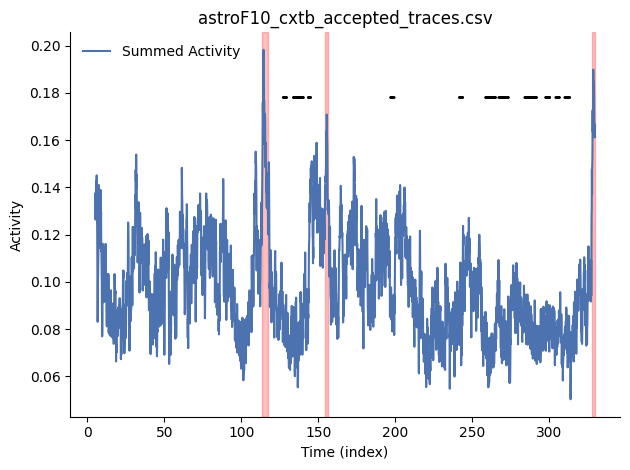

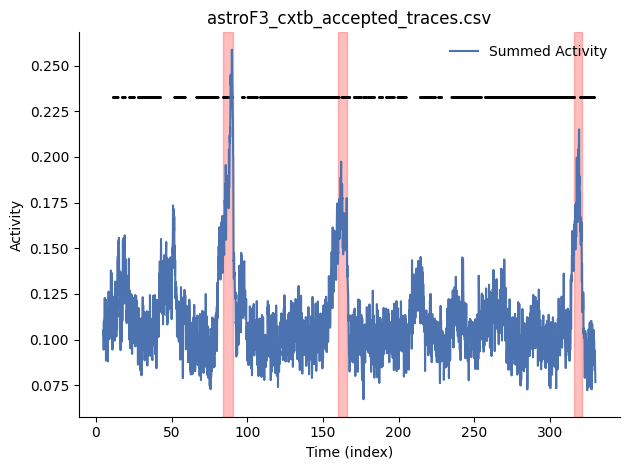

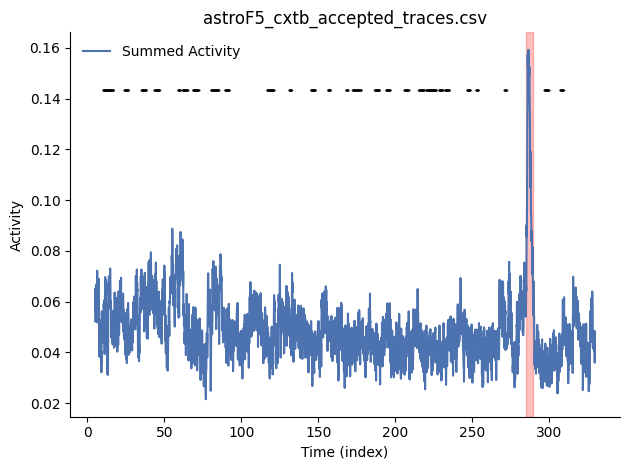

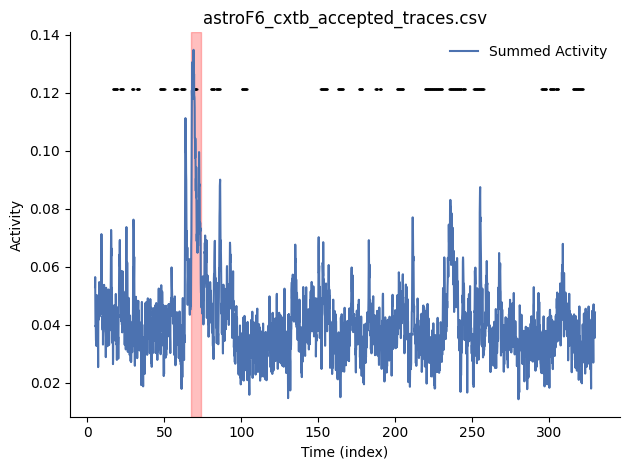

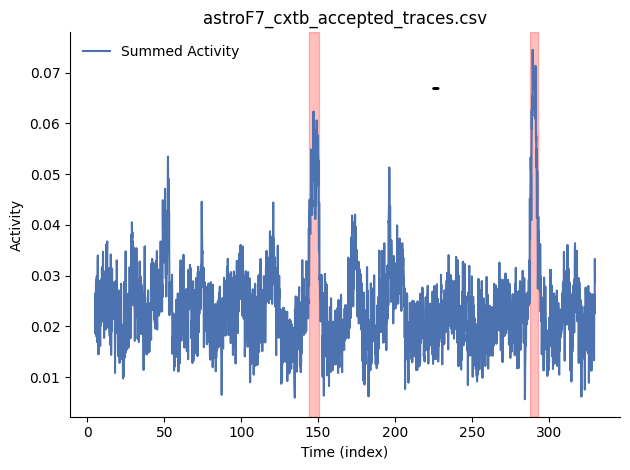

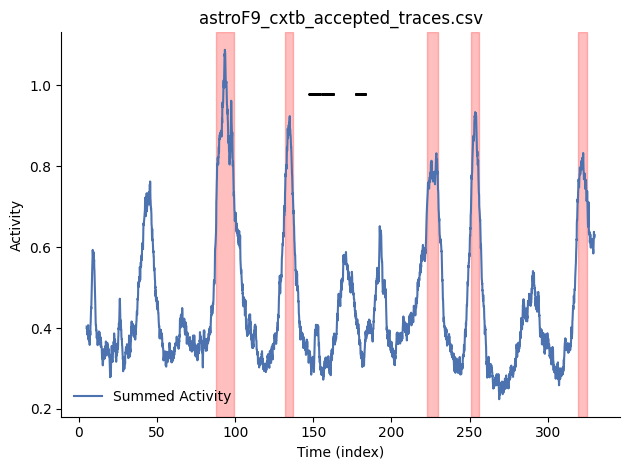

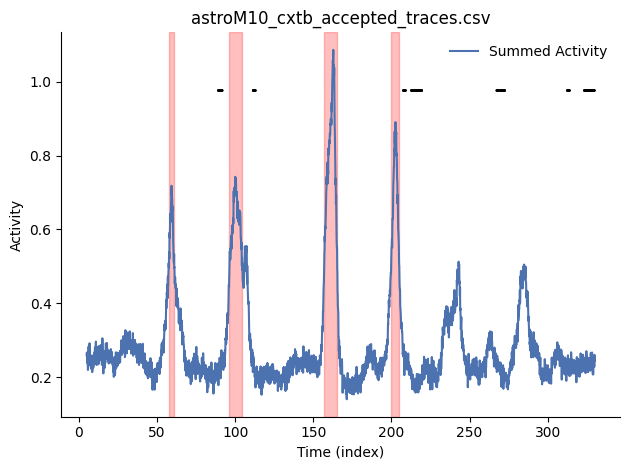

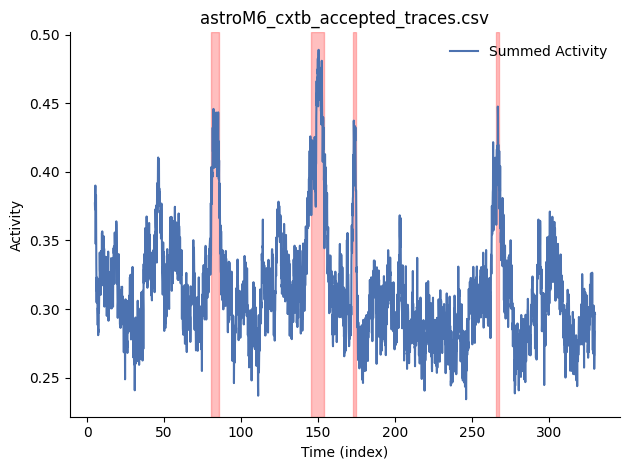

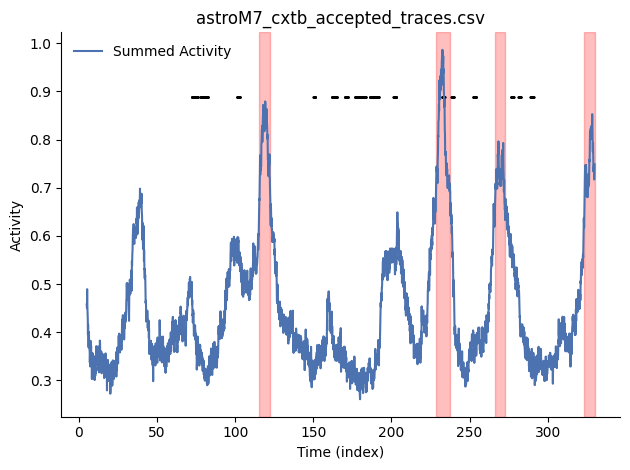

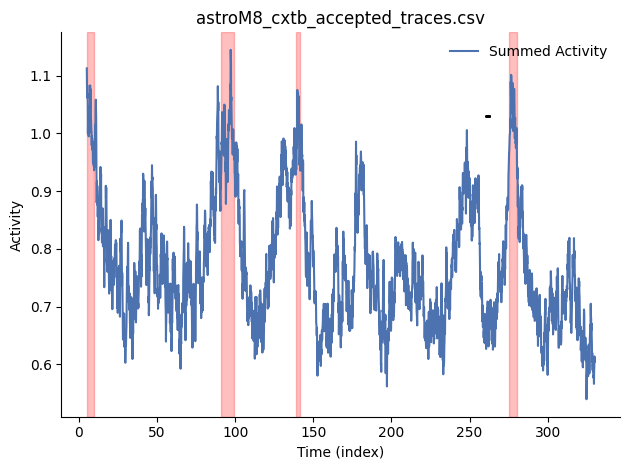

In [88]:
ddir_b = os.path.join(base_dir, "cxtb_traces_csv")

# build dicts keyed by a shared base name
csv_files_b = {
    f.replace("_accepted_traces.csv", ""): f
    for f in os.listdir(ddir_b)
    if f.endswith("accepted_traces.csv") and "astro" in f
}

time_vecs_b = {
    f.replace("_freeze_vec_cxt_b.csv", ""): f
    for f in os.listdir(ddir_b)
    if f.endswith("freeze_vec_cxt_b.csv")
}

# read each traces file into a dict of DataFrames
named_dfs_b = {
    fname: pd.read_csv(os.path.join(ddir_b, fname))
    for fname in csv_files_b.values()
}

results_b = {}
for key, df in named_dfs_b.items():
    data = process_df(df)
    events = detect_sequences_simple(
        data,
        k=1.5,
        min_duration=20,
        separation_duration=100,
    )
    results_b[key] = {
        "activity": data,
        "events": events,
    }

# find animals that have *both* traces and freeze vecs
animal_ids = sorted(
    set(k.replace("_cxtb", "") for k in csv_files_b.keys())  # astroF10_cxtb -> astroF10
    & set(time_vecs_b.keys())                                # astroF10
)

for animal in animal_ids:
    trace_key = animal + "_cxtb"                 # e.g. "astroF10_cxtb"
    trace_file = csv_files_b[trace_key]         # "astroF10_cxtb_accepted_traces.csv"
    freeze_file = time_vecs_b[animal]           # "astroF10_freeze_vec_cxt_b.csv"

    print(trace_file, "<->", freeze_file)

    time_vec = pd.read_csv(os.path.join(ddir_b, freeze_file)).to_numpy().squeeze()
    plot_file_results(trace_file, results_b, freeze_vector=time_vec)
    plt.savefig(base_dir + r"\seq_plots" + f"{trace_file}_sequences.svg")


In [85]:
named_dfs_b

{'astroF10_cxtb_accepted_traces.csv':           C010      C015      C016      C017      C018      C020      C022  \
 0     0.021062 -0.001694  0.000070  0.008148  0.000920  0.002409 -0.001164   
 1     0.013004 -0.002391  0.000687  0.004571 -0.000503  0.001990 -0.001877   
 2     0.012525 -0.002439 -0.000654  0.003277  0.002408 -0.000216 -0.001527   
 3     0.011766 -0.003181 -0.001554  0.004056  0.000809  0.001367 -0.000929   
 4     0.010768 -0.003017 -0.000685  0.003412  0.000573  0.002935 -0.001781   
 ...        ...       ...       ...       ...       ...       ...       ...   
 3298  0.001010  0.001549  0.001601  0.001602  0.001060 -0.000408  0.001746   
 3299  0.000971  0.001176  0.003659  0.000539  0.000393  0.001130  0.001089   
 3300 -0.000366  0.000124  0.003891  0.000591  0.000400  0.001149  0.002116   
 3301 -0.000485  0.000392  0.002316  0.000076 -0.001061  0.001850  0.000809   
 3302  0.000347  0.001207  0.001492  0.001391 -0.000162  0.000184  0.000903   
 
           C0

In [76]:
time_vecs_a

{'astroF10': 'astroF10_freeze_vec_cxt_a.csv',
 'astroF3': 'astroF3_freeze_vec_cxt_a.csv',
 'astroF5': 'astroF5_freeze_vec_cxt_a.csv',
 'astroF6': 'astroF6_freeze_vec_cxt_a.csv',
 'astroF7': 'astroF7_freeze_vec_cxt_a.csv',
 'astroF9': 'astroF9_freeze_vec_cxt_a.csv',
 'astroM10': 'astroM10_freeze_vec_cxt_a.csv',
 'astroM3': 'astroM3_freeze_vec_cxt_a.csv',
 'astroM4': 'astroM4_freeze_vec_cxt_a.csv',
 'astroM5': 'astroM5_freeze_vec_cxt_a.csv',
 'astroM9': 'astroM9_freeze_vec_cxt_a.csv'}

In [52]:
time.shape

(3602, 1)

In [45]:
time_vec = pd.read_csv(os.path.join(ddir_a, time_vecs_a[1])).to_numpy().squeeze()

In [47]:
time_vec.shape

(3601,)

In [72]:
named_dfs_a

{'astroF10_cxta_accepted_traces.csv':            C00       C01           C02       C03       C05       C08  \
 0     0.001084  0.008473  5.646701e-04  0.002626  0.039271 -0.000173   
 1     0.000171  0.006386 -6.073134e-04  0.002378  0.028646  0.001169   
 2    -0.001893  0.005320 -2.252010e-03 -0.000655  0.025066  0.001684   
 3    -0.000704  0.003012  2.608237e-04  0.001323  0.021286  0.000832   
 4    -0.000533  0.002423  1.692847e-04 -0.001140  0.018499 -0.000657   
 ...        ...       ...           ...       ...       ...       ...   
 3597  0.001230  0.001792  1.429950e-03  0.001731  0.002733  0.001467   
 3598  0.001999  0.002927  3.425677e-04  0.000361  0.001158  0.001446   
 3599  0.001152  0.001318  4.919453e-04  0.000565 -0.000090  0.002628   
 3600  0.002574  0.001860  8.108838e-04  0.001396  0.000986 -0.000504   
 3601  0.003573  0.002828 -1.029389e-07  0.000368  0.002454  0.000095   
 
            C09       C10       C11       C12  ...       C63       C64  \
 0     0.00